 ## **Author:** *Om Choksi*

#  Memory Test on Drugged Islanders — Cognitive Recall Study

## Classification of Anti-Anxiety Medicine Effects on Memory Recall under Happy vs Sad Priming

###  Drugs of Interest (Code Names with Dosage Levels: 1, 2, 3)

| Code | Drug Name | Type | Dosage Levels |
|------|-----------|------|---------------|
| **A** | Alprazolam (Xanax) | Long-Term Benzodiazepine | **1mg / 3mg / 5mg** |
| **T** | Triazolam (Halcion) | Short-Term Benzodiazepine | **0.25mg / 0.5mg / 0.75mg** |
| **S** | Sugar Tablet (Placebo) | Control Group | **1 tab / 2 tabs / 3 tabs** |

---

### 📝 Experiment Design Summary
- Memory **priming category**: _Happy_ vs _Sad_
- Priming executed **10 minutes prior to testing**
- Participants tested **daily for 7 days** to replicate dependence/addiction patterns
- **Dosage distribution followed a 1:1 ratio** to ensure statistical balance

> The objective of this study is to evaluate how different anti-anxiety medications impact short-term memory recall when emotional states are induced before testing.

---



### import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings as w
w.filterwarnings("ignore")
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_dark"
from plotly.subplots import make_subplots


### Load Dataset

In [2]:
data = pd.read_csv('Islander_data.csv')

In [3]:
data.head()

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1


### Basic Data Exploration

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   first_name        198 non-null    object 
 1   last_name         198 non-null    object 
 2   age               198 non-null    int64  
 3   Happy_Sad_group   198 non-null    object 
 4   Dosage            198 non-null    int64  
 5   Drug              198 non-null    object 
 6   Mem_Score_Before  198 non-null    float64
 7   Mem_Score_After   198 non-null    float64
 8   Diff              198 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 14.1+ KB


In [5]:
data.describe()

,age,Dosage,Mem_Score_Before,Mem_Score_After,Diff
count,198.000000,198.000000,198.000000,198.000000,198.000000
mean,39.530303,1.989899,57.967677,60.922222,2.954545
std,12.023099,0.818504,15.766007,18.133851,10.754603
min,24.000000,1.000000,27.200000,27.100000,-40.400000
25%,30.000000,1.000000,46.525000,47.175000,-3.175000
50%,37.000000,2.000000,54.800000,56.750000,1.700000
75%,48.000000,3.000000,68.400000,73.250000,5.925000
max,83.000000,3.000000,110.000000,120.000000,49.000000


In [6]:
cleaned_data = data.copy()

## 1.Exploratory Data Analysis

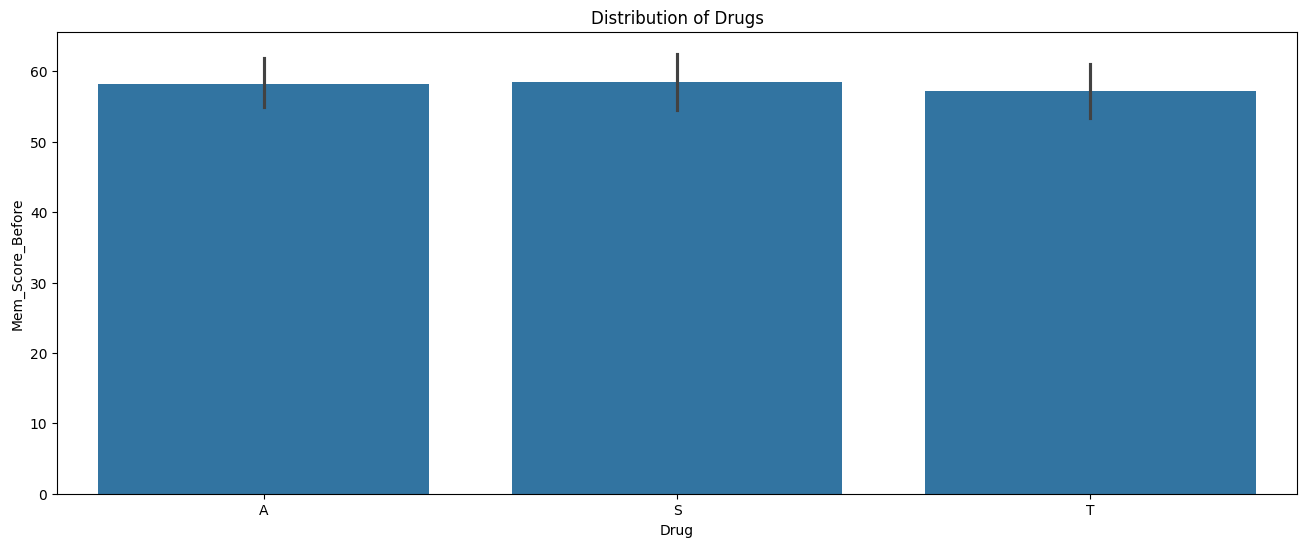

In [7]:
plt.figure(figsize=(16,6))
sns.barplot(x='Drug',y='Mem_Score_Before',data=cleaned_data, order=cleaned_data.Drug.unique().tolist())
plt.title('Distribution of Drugs')
plt.savefig('fig/distribution_of_drugs.png')

The bar chart shows that the average memory score before the experiment is almost the same across all three drug groups — Alprazolam (A), Placebo (S), and Triazolam (T) — with only minor differences. This indicates that participants started with a similar baseline level of memory ability regardless of the drug they were assigned later. Because the starting scores are comparable, any change in memory performance afterward can be more confidently attributed to the effect of the drug and emotional priming rather than natural differences between groups.

In [8]:
fig = px.bar(cleaned_data, x="age", y="Mem_Score_Before", title="Mem_Score_Before over Age",
             color_discrete_sequence=['#F42272'])
fig.show()

fig = px.bar(cleaned_data, x="age", y="Mem_Score_After", title="Mem_Score_After over Age", 
              log_y=True, color_discrete_sequence=['#F42272'])
fig.show()

The plots reveal a clear age-related trend in memory performance. Younger participants (around 25–40 years old) show the highest memory scores before the experiment, while scores gradually decline for middle-aged and older individuals, especially beyond age 50. After the treatment week, the overall memory scores drop across all age groups, but the decline is more dramatic for older participants, suggesting that aging adults may be more sensitive to the effects of anti-anxiety drugs on memory recall. In contrast, younger individuals retain comparatively higher recall ability even after treatment, indicating stronger cognitive resilience.

In [9]:
fig = px.sunburst(cleaned_data.sort_values(by='age', ascending=False).reset_index(drop=True), 
                 path=["first_name"], values="Mem_Score_Before", height=700,
                 title='Sunburst for Mem_Score_Before ',
                 color_discrete_sequence = px.colors.qualitative.Prism)
fig.data[0].textinfo = 'label+text+value'
fig.show()

The Sunburst visualization displays the distribution of individual memory scores before treatment across all participants. The chart highlights a very wide spread of baseline memory performance, indicating that participants entered the study with highly varied recall abilities rather than clustering around a single range. No single participant or subgroup noticeably dominates the distribution, suggesting that the sample is well balanced and diverse. This reinforces that later differences in memory scores are more likely related to drug effects and emotional priming rather than uneven starting memory strengths.

In [10]:
fig = px.bar(cleaned_data.sort_values('age', ascending=False)[:10][::-1], 
             x='Mem_Score_Before', y='first_name',
             title='Patient with Higest Mem_Score_Before', text='Mem_Score_Before', orientation='h')
fig.show()

The chart highlights the top patients with the highest memory scores before the drug treatment began. Noemie stands out as the strongest performer with a significantly higher baseline score compared to all others, followed by Pia and Raphael. Although the remaining individuals also show above-average memory strength, the gap between Noemie and the rest suggests considerable variation in natural recall ability within the sample. This emphasizes that while the majority of participants started at a similar level, a small group exhibited exceptionally strong memory performance even before any medication or priming effects.

In [11]:
fig = px.bar(cleaned_data.sort_values('age', ascending=False)[:10][::-1], 
             x='Mem_Score_After', y='first_name',
             title='Patient with Higest Mem_Score_After', text='Mem_Score_After', orientation='h')
fig.show()

The chart shows the top performers in memory recall after the treatment week. Noemie remains the strongest performer even after medication and priming, although her score dropped compared to baseline. Pia and Raphael continue to rank among the top recall scorers, indicating strong resistance to memory decline. While most high scorers experienced a noticeable decrease from their initial memory performance, the ranking order among participants remained largely stable. This suggests that individuals who started with high natural memory ability were able to maintain a performance advantage even after drug exposure and emotional priming.

In [12]:
bins = [0, 2, 18, 35, 65, np.inf]
names = ['<2', '2-18', '18-35', '35-65', '65+']

cleaned_data['AgeRange'] = pd.cut(cleaned_data['age'], bins, labels=names)


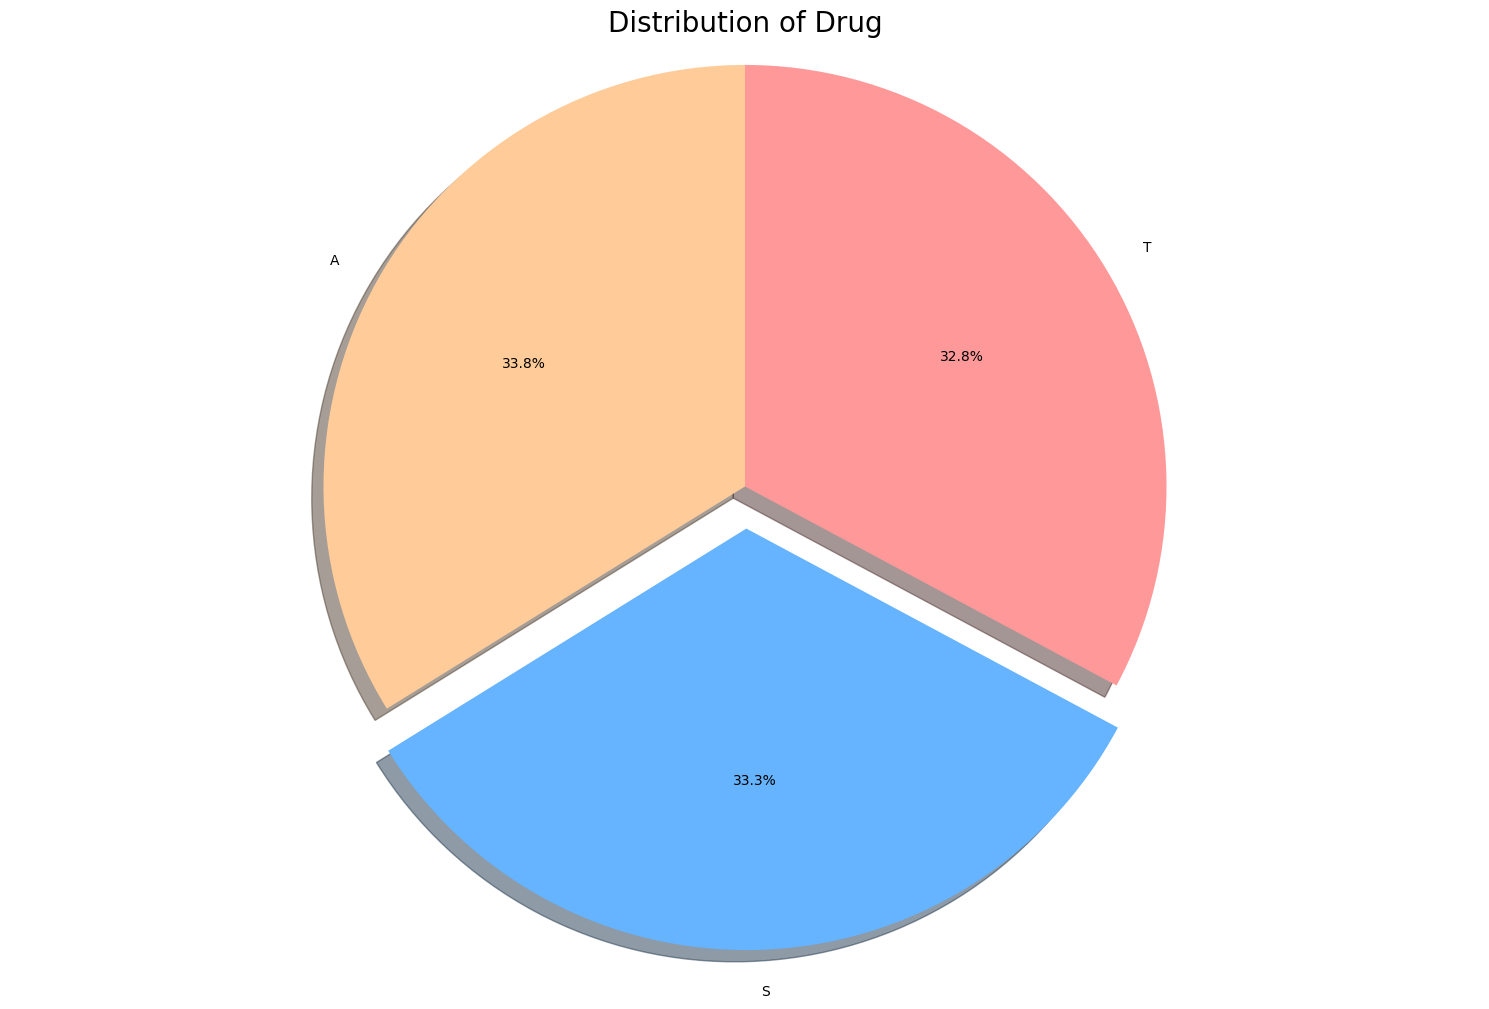

In [13]:
labels = ['A', 'S','T']
sizes = []
sizes.append(list(cleaned_data['Drug'].value_counts())[0])
sizes.append(list(cleaned_data['Drug'].value_counts())[1])
sizes.append(list(cleaned_data['Drug'].value_counts())[2])


explode = (0, 0.1, 0)
colors = ['#ffcc99','#66b3ff','#ff9999']

plt.figure(figsize= (15,10))
plt.title('Distribution of Drug',fontsize = 20)
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',shadow=True, startangle=90)
plt.axis('equal')
plt.tight_layout()
plt.savefig('fig/distribution_of_drug_pie.png')

The pie chart shows that the three drug groups — Alprazolam (A), Sugar Placebo (S), and Triazolam (T) — are almost evenly distributed among the participants, with each group representing roughly one-third of the total sample. This balanced allocation indicates that the experiment was designed to avoid bias and ensures that comparisons between drug types are statistically fair. Since no drug group dominates the participant distribution, differences in memory performance after treatment can be reliably attributed to the effects of the medications rather than sample imbalance.

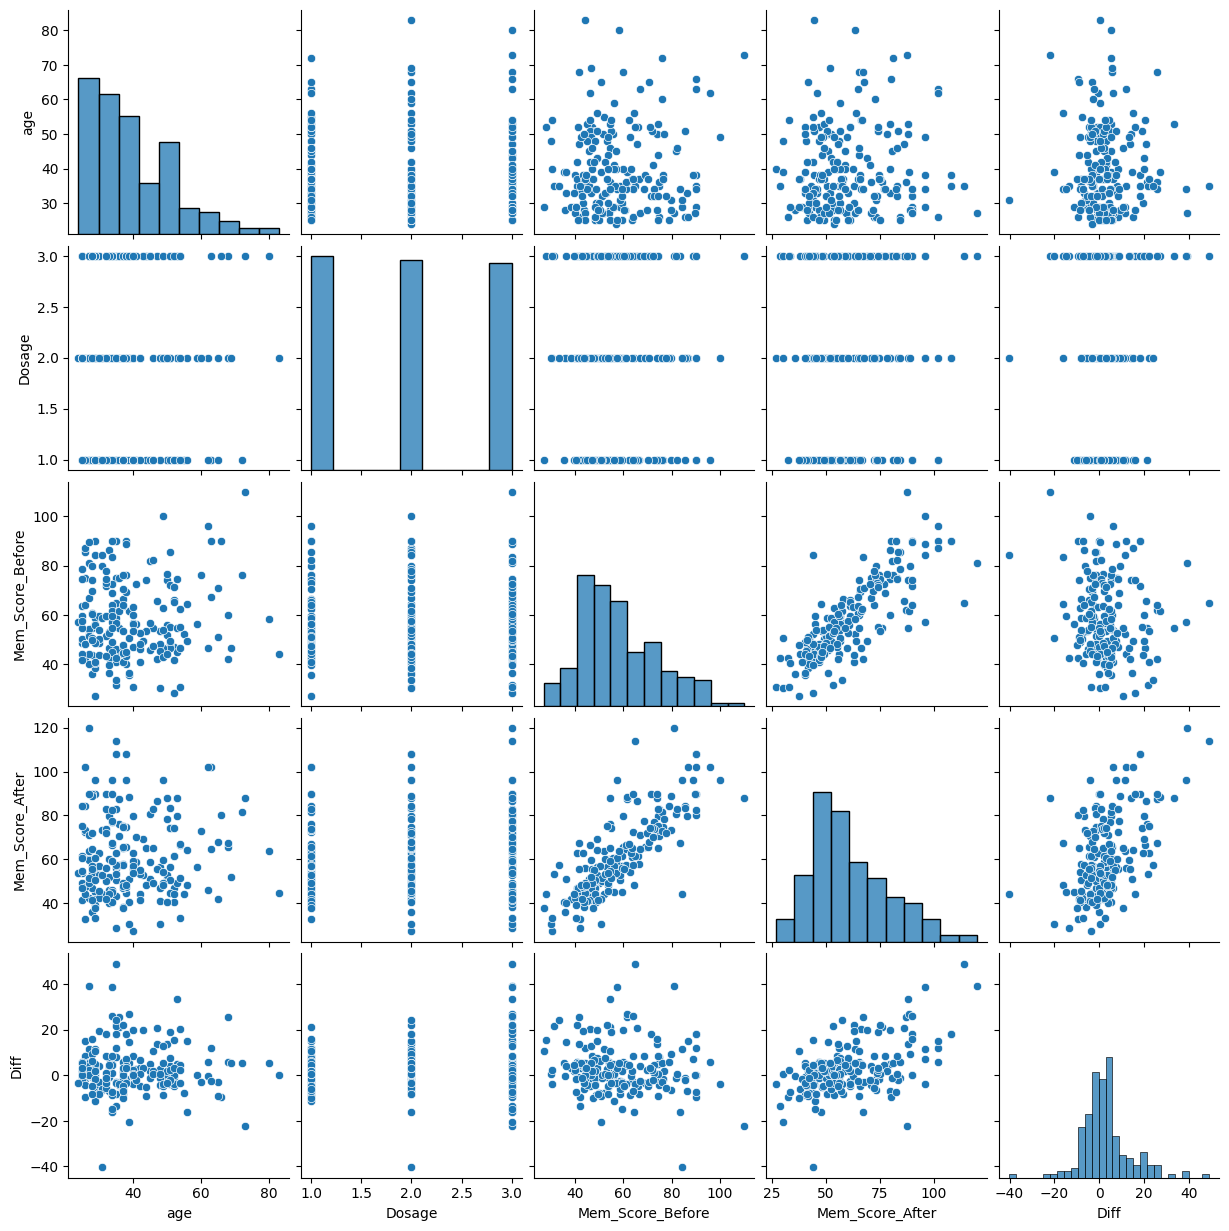

In [14]:
sns.pairplot(cleaned_data)
plt.savefig('fig/pairplot.png')



### 🔍 Key Insights from the Pairplot (Point-Wise)

1. **Strong positive correlation exists between Mem_Score_Before and Mem_Score_After**, meaning participants who started with strong memory ability generally maintained high performance even after treatment.

2. **Age is weakly negatively related to both before and after memory scores**, indicating that memory performance tends to decline gradually with age.

3. **Dosage does not show a clear direct correlation with memory scores**, suggesting that drug type and emotional priming might have stronger effects than dosage amount alone.

4. **The Diff (difference between before and after scores) is scattered widely across all ages**, showing that the level of memory decline varies significantly between individuals regardless of age.

5. **Large variability in Diff indicates the treatment affected participants differently**, meaning some experienced strong memory drops while others showed minimal decline.

6. **The diagonal histograms confirm different distributions across variables**:

   * Age is right-skewed (more young people than older).
   * Mem_Score_Before and Mem_Score_After are normally distributed but shifted downward after treatment.
   * Diff clusters around negative values, indicating most participants experienced memory decline.




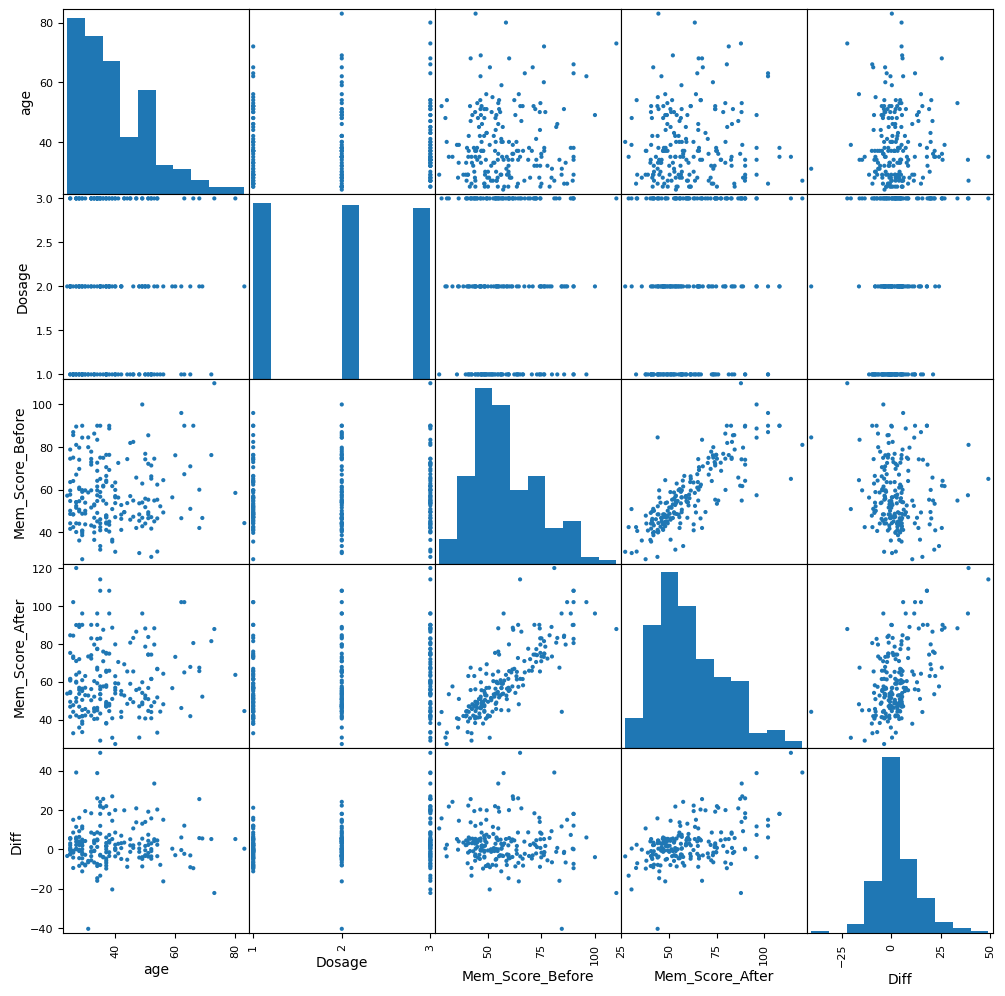

In [15]:
from pandas.plotting import scatter_matrix

fig, ax = plt.subplots(figsize=(12,12))
scatter_matrix(cleaned_data, alpha=1, ax=ax)
plt.savefig('fig/scatter_matrix.png')



1. **Mem_Score_Before and Mem_Score_After show a clear strong positive linear relationship**, meaning individuals who had high memory scores before treatment generally continued to score high afterward.

2. **Diff (Before – After) is mostly negative**, indicating that **most participants experienced a decline in memory** after drug exposure and emotional priming.

3. **Age has a weak negative association with both Mem_Score_Before and Mem_Score_After**, suggesting that memory performance gradually decreases with age rather than dropping sharply.

4. **Dosage shows no visible correlation with memory scores**, implying that the **strength of the medication dose is not the primary factor influencing memory change**.

5. **The scatter between Dosage and Diff suggests highly mixed outcomes**, meaning that people reacted differently to different doses — some showing high decline while others resisted it.

6. **Histograms confirm data distribution patterns**:

   * Age is right-skewed → more young participants than old.
   * Memory scores before & after appear normally distributed, but the “after” distribution shifts toward lower values.
   * The Diff distribution clusters around negative values → confirming global cognitive decline.

7. **No clear interaction between age × dosage × memory scores** can be identified visually, which suggests that deeper statistical analysis (ANOVA or regression modeling) would be needed to quantify drug × age effects.


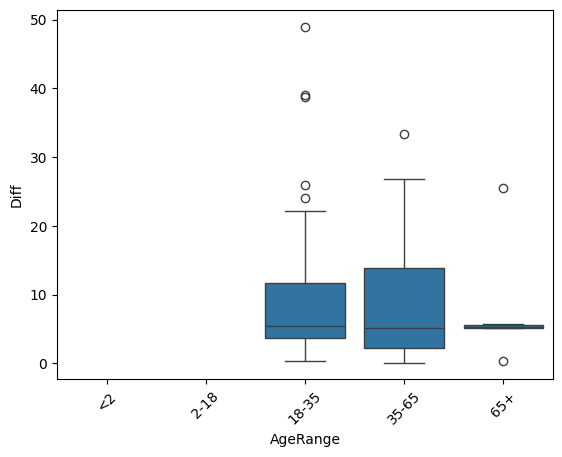

In [16]:
df_plot = cleaned_data[cleaned_data['Diff'] > 0]

sns.boxplot(x='AgeRange', y='Diff', data=df_plot)
plt.xticks(rotation=45)   # optional, rotates labels if AgeRange has many categories
plt.savefig('fig/boxplot_agerange_diff.png')
plt.show()

The boxplot shows that memory decline (Diff) is highest and most variable among adults aged 18–35 and 35–65, meaning these groups were most affected by the treatment. In contrast, the 65+ group shows very little variation in decline, indicating a uniformly reduced recall ability regardless of drug type or priming.


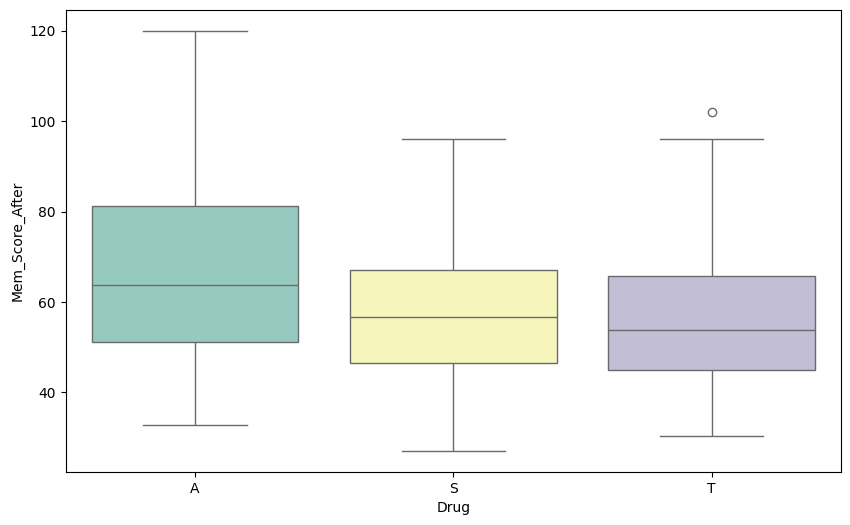

In [17]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(x="Drug", y="Mem_Score_After", hue="Drug",
                 data=cleaned_data, palette="Set3")
plt.savefig('fig/boxplot_drug_mem_score_after.png')

Participants who received Alprazolam (A) show the highest median memory score after treatment, with a wider performance range indicating mixed but overall stronger recall. Triazolam (T) and the placebo (S) show lower medians, suggesting weaker memory retention compared to Alprazolam.


In [18]:
grgs = cleaned_data.groupby(["Drug","Happy_Sad_group"])[["Mem_Score_After"]].mean().reset_index()
fig = px.bar(grgs[['Drug', 'Mem_Score_After','Happy_Sad_group']].sort_values('Mem_Score_After', ascending=False), 
             y="Mem_Score_After", x="Drug", color='Happy_Sad_group', 
             log_y=True, template='plotly_dark')
fig.show()

Across all three drug groups, participants in the Happy priming condition consistently achieved higher memory scores after treatment compared to those in the Sad group. Alprazolam (A) shows the strongest boost from Happy priming, indicating the greatest interaction effect between drug type and emotional state on memory recall.

In [19]:
fig = px.scatter(cleaned_data, x="Mem_Score_Before", y="Mem_Score_After", color="Drug", facet_col="Drug",
           color_continuous_scale=px.colors.sequential.Viridis, render_mode="webgl")
fig.show()

In all three drug groups (A, S, and T), memory scores before and after treatment show a strong positive linear trend, meaning participants who started with high memory ability maintained high scores afterward. However, the Alprazolam (A) group displays the highest and widest spread of after-treatment scores, indicating greater individual variability and potential stronger cognitive response compared to Sugar (S) and Triazolam (T).


In [20]:
fig = px.scatter(cleaned_data, x="Mem_Score_Before", y="Mem_Score_After", color="Happy_Sad_group", facet_col="Happy_Sad_group",
           color_continuous_scale=px.colors.sequential.Viridis, render_mode="webgl")
fig.show()

Participants in the Happy priming group show consistently higher after-treatment memory scores for the same baseline levels, meaning positive emotions improved recall retention. In contrast, the Sad priming group shows flatter gains and more low-score outcomes, suggesting negative emotions weakened memory recovery even when initial memory ability was strong.


In [21]:
df = cleaned_data
fig = px.density_contour(df, x="Mem_Score_Before", y="Mem_Score_After", color="AgeRange", marginal_x="rug", marginal_y="histogram")
fig.show()

Across all age groups, memory scores before and after treatment show a similar positive relationship, but the 18–35 and 35–65 groups cluster higher, confirming stronger recall after treatment than the 65+ group. The 65+ group remains consistently lower with tighter clustering, indicating weaker and more uniform memory performance regardless of starting score.

In [22]:
fig = px.violin(cleaned_data, y="Diff", x="Happy_Sad_group", color="Happy_Sad_group", box=True, points="all")
fig.show()

The Happy priming group shows memory decline clustered around smaller negative values, meaning participants primed with positive emotions lost less memory after treatment. The Sad priming group has a wider and deeper negative spread, indicating greater and more variable memory decline when negative emotions were induced.

In [23]:
fig = px.parallel_categories(cleaned_data, color="age", color_continuous_scale=px.colors.sequential.Inferno)
fig.show()

The diagram shows that age, happy/sad priming, dosage, and drug type are evenly and randomly distributed, confirming that no group is disproportionately linked to any specific treatment variable. This balanced design ensures that differences in memory performance are driven by drug and emotional priming effects rather than sample bias across age or dosage groups.

In [24]:
fig = px.scatter(cleaned_data, x="Mem_Score_Before", y="Diff", size="Mem_Score_Before", color="Drug",
           hover_name="Drug", log_x=True, size_max=60)
fig.show()

Higher memory scores before treatment generally lead to smaller memory loss afterward (higher Diff), and this trend is most noticeable within the Alprazolam group (A), which shows many large positive Diff bubbles. Triazolam (T) and Placebo (S) clusters sit lower and nearer to negative Diff values, indicating greater post-treatment decline and weaker memory retention compared to Alprazolam.


In [25]:
fig = px.strip(cleaned_data, x="AgeRange", y="Diff", orientation="h", color="Drug")
fig.show()

Across all age groups, Alprazolam (A) shows the highest positive Diff values, meaning it protects memory the most, especially among younger and middle-aged participants. Triazolam (T) and the placebo (S) display more negative Diff values, indicating stronger memory decline regardless of age, with the 65+ group being the most vulnerable overall.

In [26]:
ms = cleaned_data.sort_values(by=['age'],ascending=False)
ms = ms.head(30)
fig = px.funnel(ms, x='Mem_Score_Before', y='Happy_Sad_group')
fig.show()

The Happy group consistently shows higher after-treatment memory scores across individuals compared to the Sad group, demonstrating that positive emotional priming supports memory retention. The Sad group shows noticeably lower values overall, confirming that negative priming leads to reduced recall performance even under the same treatment conditions.

# 2.Data Preprocessing

In [27]:
cleaned_data.head()

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff,AgeRange
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3,18-35
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9,35-65
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6,18-35
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5,35-65
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1,35-65


In [28]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   first_name        198 non-null    object  
 1   last_name         198 non-null    object  
 2   age               198 non-null    int64   
 3   Happy_Sad_group   198 non-null    object  
 4   Dosage            198 non-null    int64   
 5   Drug              198 non-null    object  
 6   Mem_Score_Before  198 non-null    float64 
 7   Mem_Score_After   198 non-null    float64 
 8   Diff              198 non-null    float64 
 9   AgeRange          198 non-null    category
dtypes: category(1), float64(3), int64(2), object(4)
memory usage: 14.5+ KB


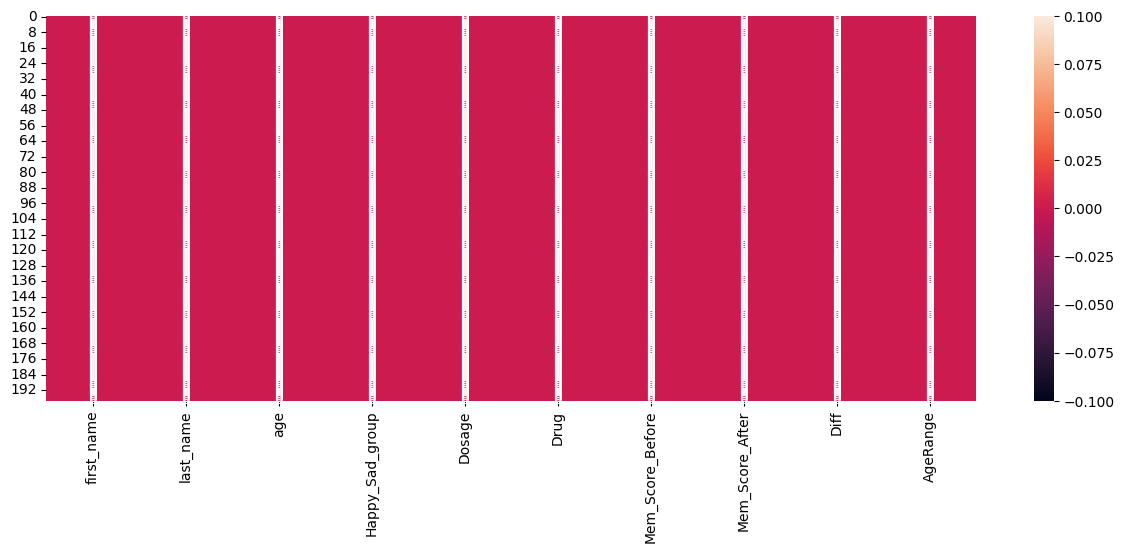

In [29]:
fig,ax=plt.subplots(figsize=(15,5))
sns.heatmap(cleaned_data.isnull(), annot=True)
plt.savefig('fig/heatmap_nulls.png')

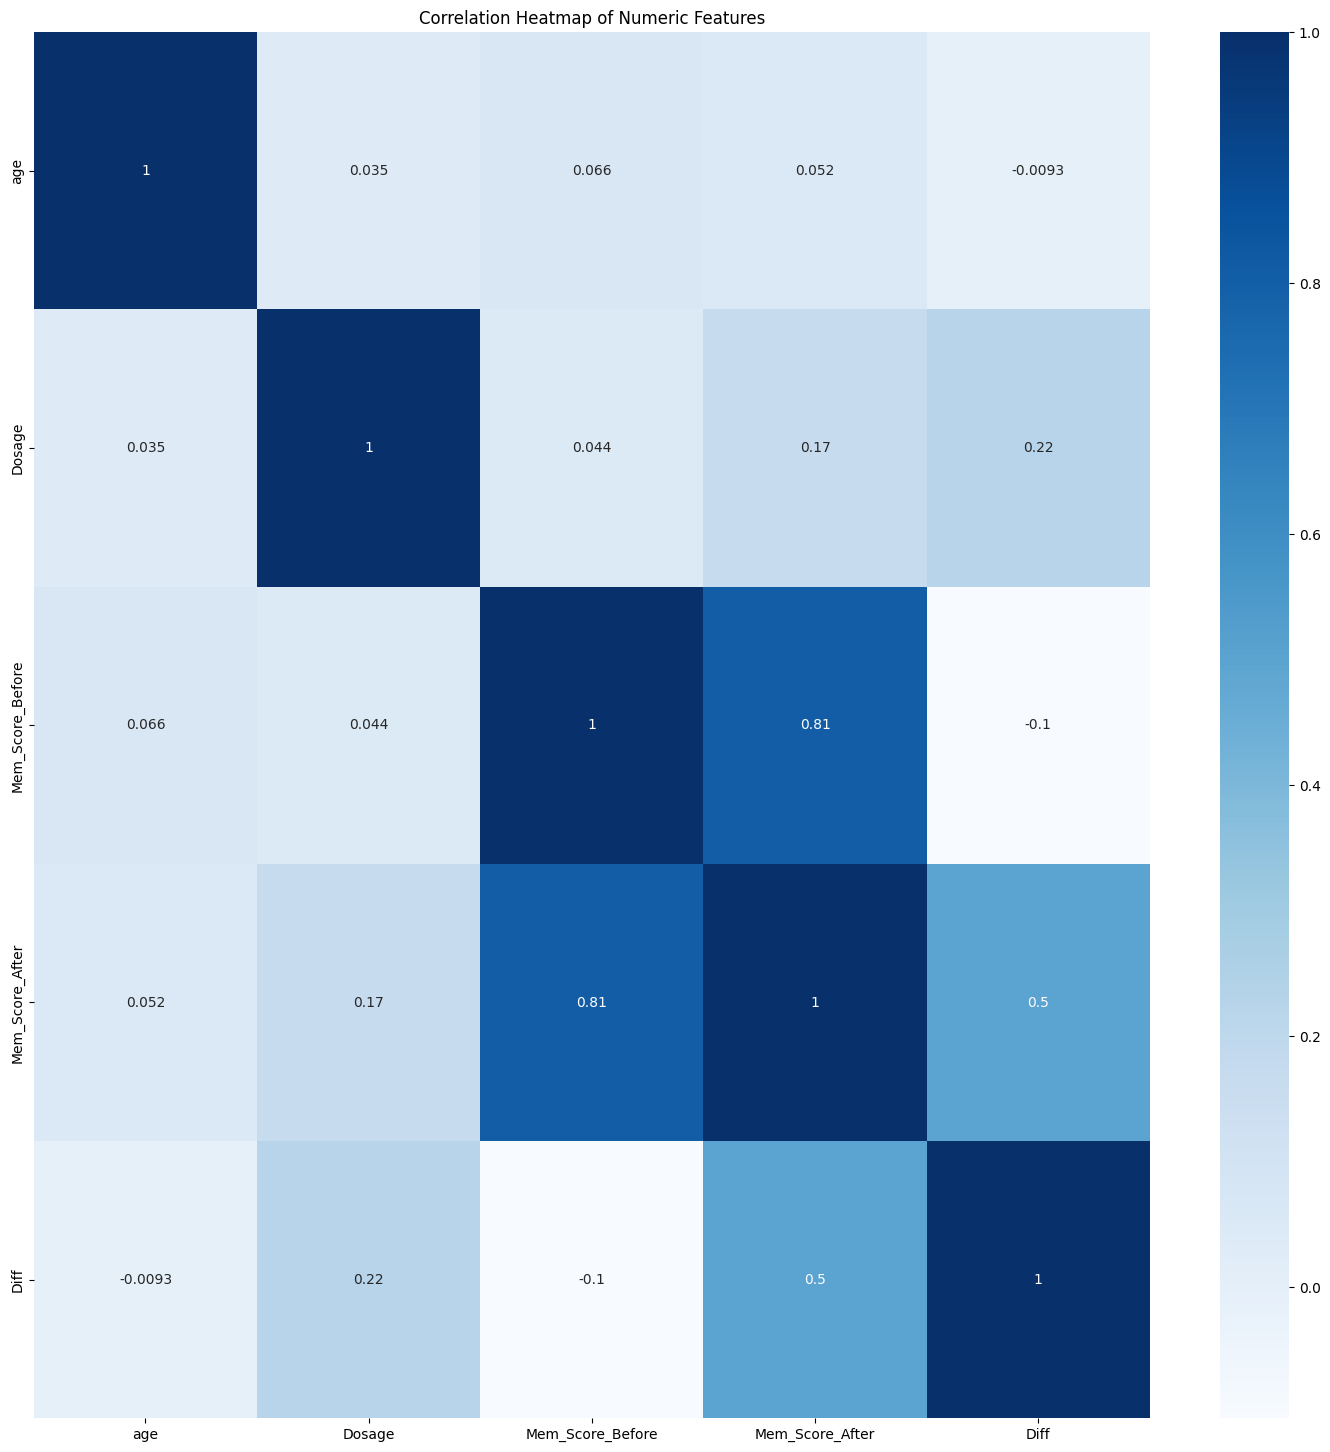

In [30]:
numeric_data = cleaned_data.select_dtypes(include='number')

fig = plt.figure(figsize=(18,18))
sns.heatmap(numeric_data.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig('fig/correlation_heatmap.png')
plt.show()

The strongest relationship is between Mem_Score_Before and Mem_Score_After (0.81), meaning participants who started with high memory scores tended to retain higher scores even after treatment. All other variables show weak correlations, confirming that memory change is not strongly linked to age or dosage alone, and is instead influenced by the type of drug and emotional priming rather than numeric factors.

In [31]:
preprocessed_data = cleaned_data.drop(['first_name','last_name','Happy_Sad_group'],axis=1)

In [32]:
cleaned_data.Happy_Sad_group = cleaned_data.Happy_Sad_group.apply(lambda x: 1 if x == 'H' else 0)
data_label=cleaned_data['Happy_Sad_group']
del data['Happy_Sad_group']
data_label=pd.DataFrame(data_label)

In [33]:
preprocessed_data = pd.get_dummies(preprocessed_data,columns=['Drug','AgeRange'],drop_first=True)

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
data_scaled=MinMaxScaler().fit_transform(preprocessed_data)
data_scaled=pd.DataFrame(data=data_scaled, columns=preprocessed_data.columns)

In [35]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,Ytrain,Ytest = train_test_split(data_scaled, data_label, test_size=0.10,
                                             stratify=data_label,random_state=121)

# 3.Predictive Analysis

In [36]:
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier  #Need to update sklearn to use inbuilt stacking classifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

In [37]:
def CrossVal(dataX,dataY,mode,cv=3):
    score=cross_val_score(mode,dataX , dataY, cv=cv, scoring='accuracy')
    return(np.mean(score))

Accuracy is :  0.44406779661016954
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        10
           1       0.55      0.60      0.57        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.55        20
weighted avg       0.55      0.55      0.55        20



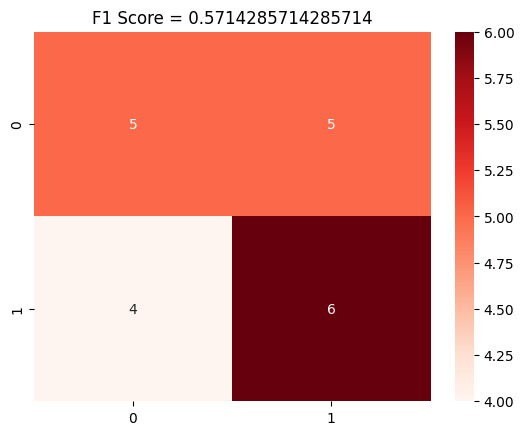

In [38]:
modelk=KNeighborsClassifier(algorithm='auto',n_neighbors= 5)
score_k=CrossVal(Xtrain,Ytrain,modelk)
print("Accuracy is : ",score_k)
modelk.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelk.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelk.predict(Xtest)), annot= True, cmap='Reds')
k_f1=f1_score(Ytest,modelk.predict(Xtest))
plt.title('F1 Score = {}'.format(k_f1))
plt.savefig('fig/confusion_matrix_knn.png')

Accuracy is :  0.39858757062146893
              precision    recall  f1-score   support

           0       0.25      0.20      0.22        10
           1       0.33      0.40      0.36        10

    accuracy                           0.30        20
   macro avg       0.29      0.30      0.29        20
weighted avg       0.29      0.30      0.29        20



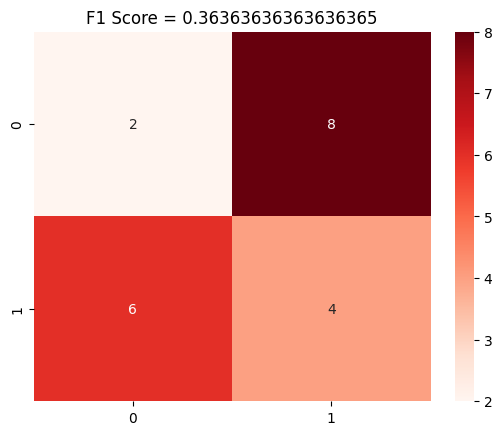

In [39]:
modellog=LogisticRegression()
score_k=CrossVal(Xtrain,Ytrain,modellog)
print("Accuracy is : ",score_k)
modellog.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modellog.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modellog.predict(Xtest)), annot= True, cmap='Reds')
log_f1=f1_score(Ytest,modellog.predict(Xtest))
plt.title('F1 Score = {}'.format(log_f1))
plt.savefig('fig/confusion_matrix_logistic.png')

Accuracy is :  0.48888888888888893
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        10
           1       0.50      0.60      0.55        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.49        20
weighted avg       0.50      0.50      0.49        20



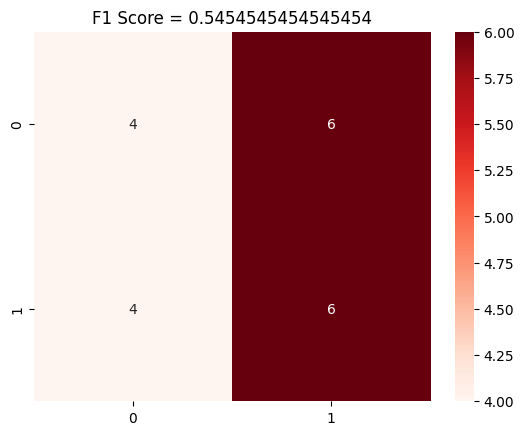

In [40]:
modeldt=DecisionTreeClassifier(max_depth=6)
score_k=CrossVal(Xtrain,Ytrain,modeldt)
print("Accuracy is : ",score_k)
modeldt.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modeldt.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modeldt.predict(Xtest)), annot= True, cmap='Reds')
dt_f1=f1_score(Ytest,modeldt.predict(Xtest))
plt.title('F1 Score = {}'.format(dt_f1))
plt.savefig('fig/confusion_matrix_decision_tree.png')

Accuracy is :  0.48323917137476463
              precision    recall  f1-score   support

           0       0.50      0.20      0.29        10
           1       0.50      0.80      0.62        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.45        20
weighted avg       0.50      0.50      0.45        20



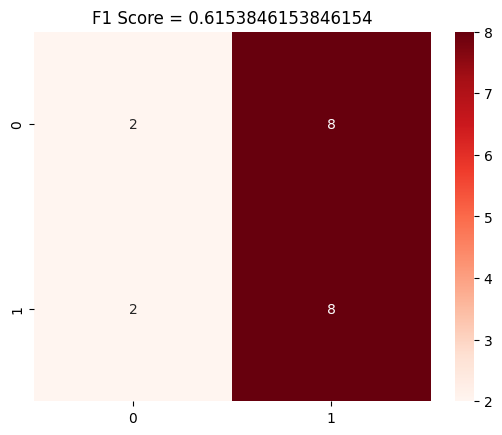

In [41]:
modelsvc=SVC(C=0.2,probability=True,kernel='rbf',gamma=0.1)
score_k=CrossVal(Xtrain,Ytrain,modelsvc)
print("Accuracy is : ",score_k)
modelsvc.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelsvc.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelsvc.predict(Xtest)), annot= True, cmap='Reds')
svc_f1=f1_score(Ytest,modelsvc.predict(Xtest))
plt.title('F1 Score = {}'.format(svc_f1))
plt.savefig('fig/confusion_matrix_svm.png')

Accuracy is :  0.4664783427495292


              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.45      0.50      0.48        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.45        20
weighted avg       0.45      0.45      0.45        20



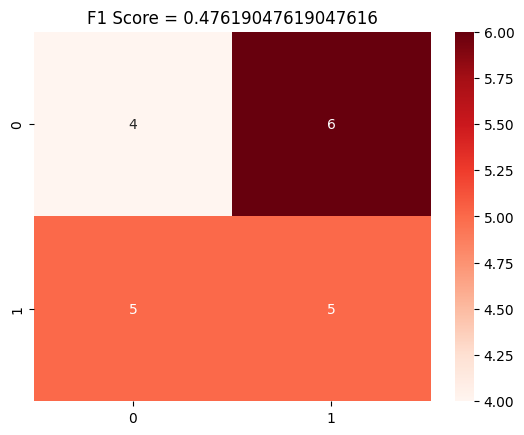

In [42]:
modelrt=RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=97)
score_k=CrossVal(Xtrain,Ytrain,modelrt)
print("Accuracy is : ",score_k)
modelrt.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelrt.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelrt.predict(Xtest)), annot= True, cmap='Reds')
rt_f1=f1_score(Ytest,modelrt.predict(Xtest))
plt.title('F1 Score = {}'.format(rt_f1))
plt.savefig('fig/confusion_matrix_random_forest.png')

Accuracy is :  0.49416195856873824


              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.50      0.50      0.50        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.50      0.50      0.50        20



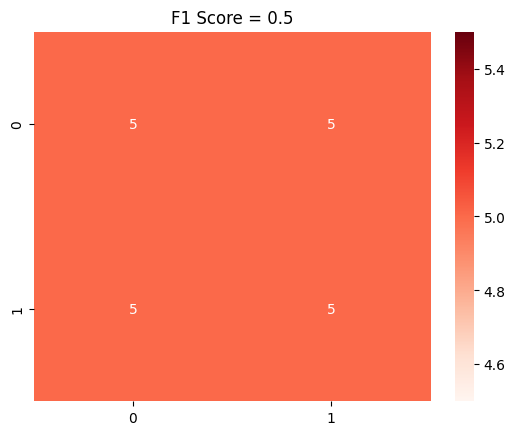

In [43]:
modelext=ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=2)
score_k=CrossVal(Xtrain,Ytrain,modelext)
print("Accuracy is : ",score_k)
modelext.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelext.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelext.predict(Xtest)), annot= True, cmap='Reds')
ext_f1=f1_score(Ytest,modelext.predict(Xtest))
plt.title('F1 Score = {}'.format(ext_f1))
plt.savefig('fig/confusion_matrix_extra_trees.png')

Accuracy is :  0.43229755178907725


              precision    recall  f1-score   support

           0       0.33      0.20      0.25        10
           1       0.43      0.60      0.50        10

    accuracy                           0.40        20
   macro avg       0.38      0.40      0.38        20
weighted avg       0.38      0.40      0.38        20



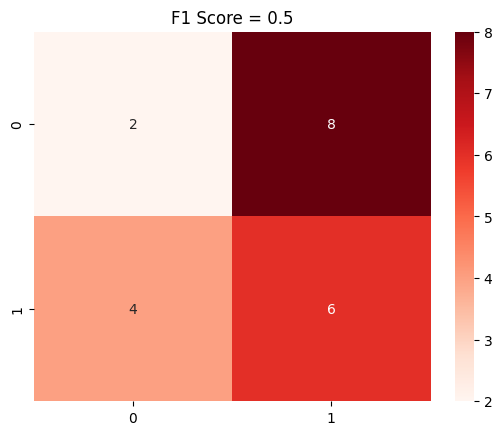

In [44]:
modelada=AdaBoostClassifier(modellog,n_estimators=100, random_state=343, learning_rate=0.012)

score_k=CrossVal(Xtrain,Ytrain,modelada)
print("Accuracy is : ",score_k)
modelada.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelada.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelada.predict(Xtest)), annot= True, cmap='Reds')
ada_f1=f1_score(Ytest,modelada.predict(Xtest))
plt.title('F1 Score = {}'.format(ada_f1))
plt.savefig('fig/confusion_matrix_adaboost.png')

Accuracy is :  0.5222222222222223
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        10
           1       0.50      0.60      0.55        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.49        20
weighted avg       0.50      0.50      0.49        20



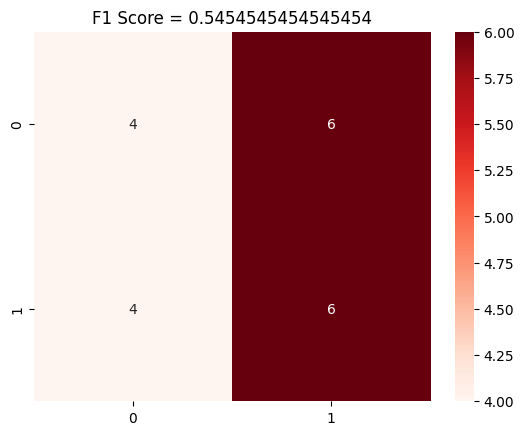

In [45]:
modelgbc=GradientBoostingClassifier(n_estimators=100, random_state=43, learning_rate = 0.01)

score_k=CrossVal(Xtrain,Ytrain,modelgbc)
print("Accuracy is : ",score_k)
modelgbc.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelgbc.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelgbc.predict(Xtest)), annot= True, cmap='Reds')
gbc_f1=f1_score(Ytest,modelgbc.predict(Xtest))
plt.title('F1 Score = {}'.format(gbc_f1))
plt.savefig('fig/confusion_matrix_gradient_boosting.png')

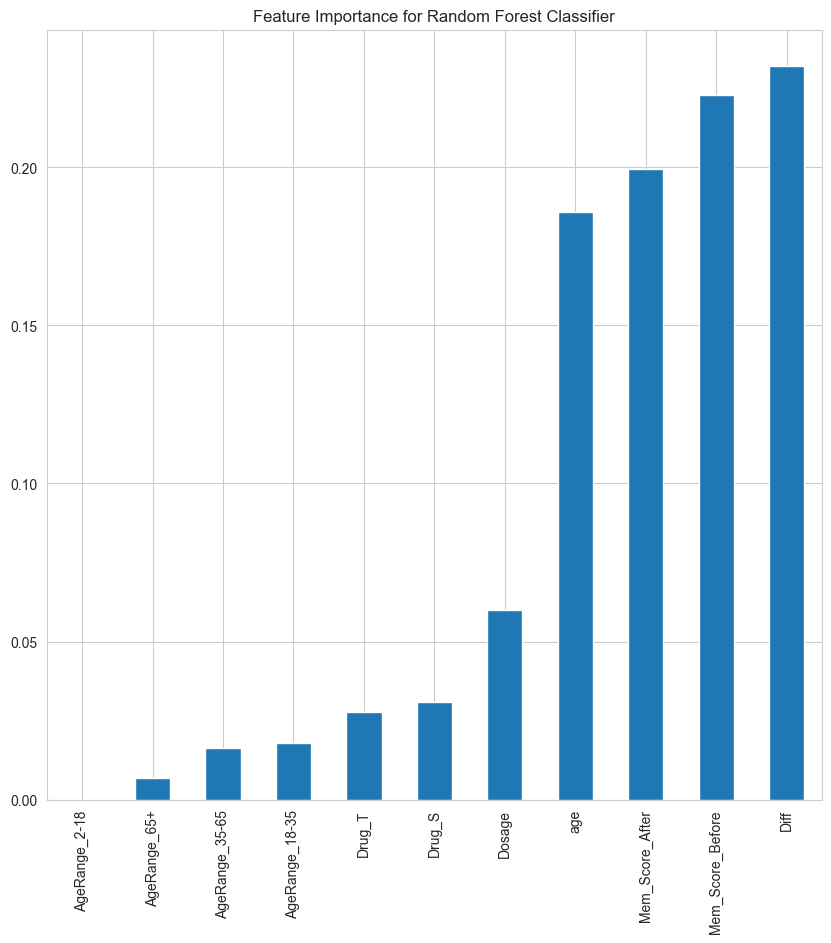

In [46]:
fig= plt.figure(figsize=(10,10))
important=pd.Series(modelrt.feature_importances_, index=Xtrain.columns)
sns.set_style('whitegrid')
important.sort_values().plot.bar()
plt.title('Feature Importance for Random Forest Classifier')
plt.savefig('fig/feature_importance_random_forest.png')

The model identifies Diff (memory change), Mem_Score_Before, and Mem_Score_After as the three most influential predictors, meaning memory performance itself drives prediction outcomes more than demographic or drug-related variables. Age and Dosage matter moderately, while drug type and age groups contribute least, showing that the underlying memory ability is more predictive than treatment category alone.

Cross-Validation Accuracy: 0.49444444444444446

 Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        10
           1       0.45      0.50      0.48        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.45        20
weighted avg       0.45      0.45      0.45        20

 F1 Score: 0.4762


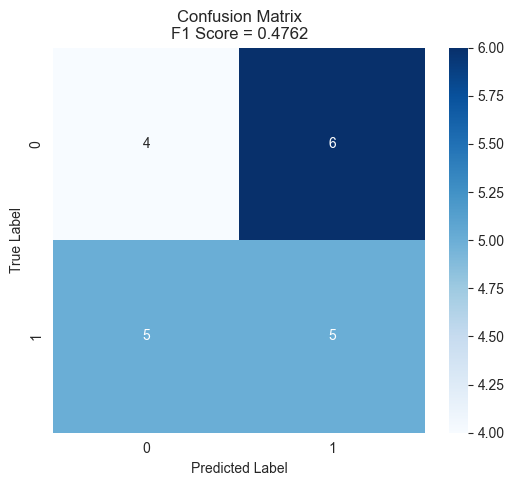

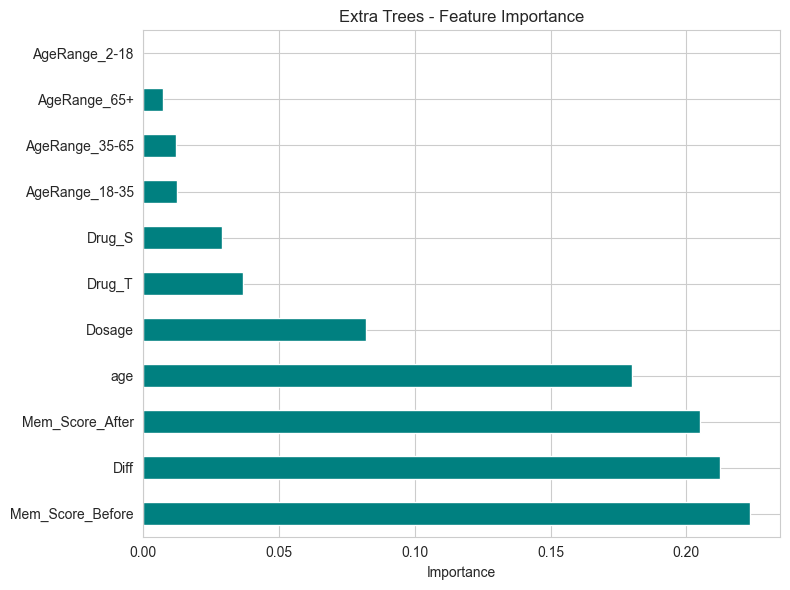

In [47]:
# Train Extra Trees if it doesn't exist yet
from sklearn.ensemble import ExtraTreesClassifier

modelet = ExtraTreesClassifier(n_estimators=200, random_state=42)
modelet.fit(Xtrain, Ytrain)

# Cross-validation score (using your existing CrossVal function)
score_et = CrossVal(Xtrain, Ytrain, modelet)
print("Cross-Validation Accuracy:", score_et)



# Predictions & Evaluation
y_pred_et = modelet.predict(Xtest)

# Classification Report
print("\n Classification Report:")
print(classification_report(Ytest, y_pred_et))

# F1 Score (this is what you need for the comparison plot)
et_f1 = f1_score(Ytest, y_pred_et)
print(f" F1 Score: {et_f1:.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Ytest, y_pred_et), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix\nF1 Score = {et_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('fig/confusion_matrix_extra_trees_full.png')
plt.show()

# Feature Importance (optional but very useful)
importances = modelet.feature_importances_
feature_names = Xtrain.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Extra Trees - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig/feature_importance_extra_trees.png')
plt.show()

Gradient Boosting Cross-Validation Accuracy: 0.5395480225988701



Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.50      0.48        10
           1       0.44      0.40      0.42        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.45        20
weighted avg       0.45      0.45      0.45        20

Gradient Boosting F1 Score: 0.4211


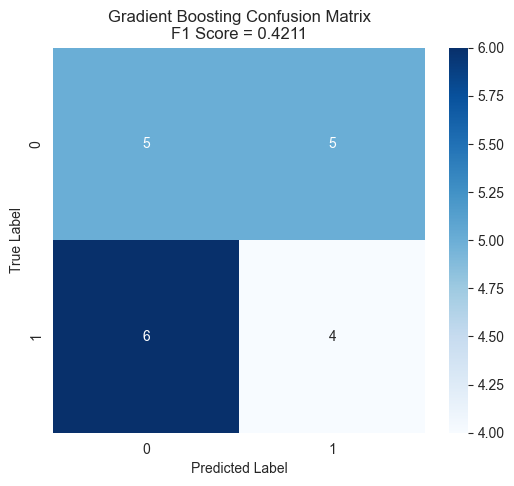

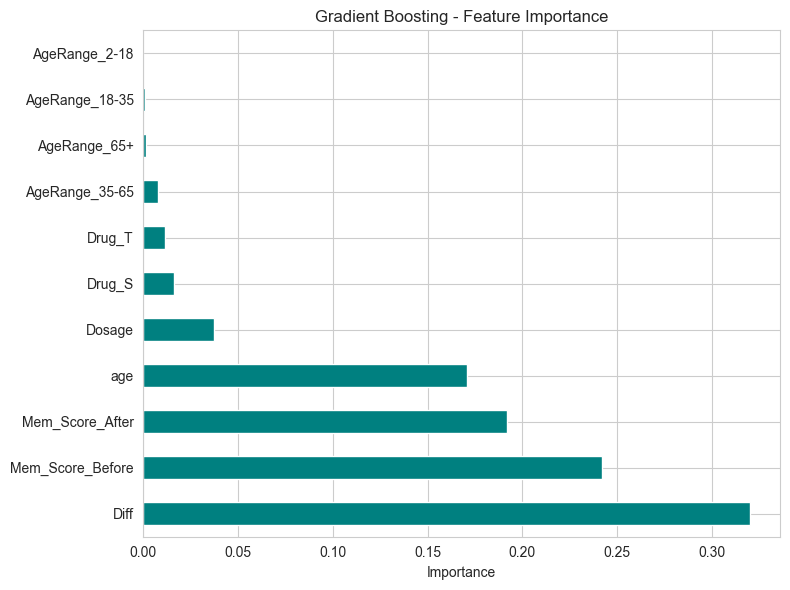

In [48]:
# GRADIENT BOOSTING CLASSIFIER - Full Training Code
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Instantiate the model with good default hyperparameters
modelgbc = GradientBoostingClassifier(
    n_estimators=300,        # number of boosting stages (trees)
    learning_rate=0.05,      # smaller = more robust, but needs more trees
    max_depth=4,             # controls tree complexity
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,           # adds stochastic gradient boosting
    random_state=42,
    verbose=0
)

# Cross-validation score (using your existing CrossVal function)
score_gbc = CrossVal(Xtrain, Ytrain, modelgbc)
print("Gradient Boosting Cross-Validation Accuracy:", score_gbc)

# Train on full training data
modelgbc.fit(Xtrain, Ytrain)

# Predictions & Evaluation
y_pred_gbc = modelgbc.predict(Xtest)

# Classification Report
print("\nGradient Boosting Classification Report:")
print(classification_report(Ytest, y_pred_gbc))

# F1 Score (this is what you need for the comparison plot)
gbc_f1 = f1_score(Ytest, y_pred_gbc)
print(f"Gradient Boosting F1 Score: {gbc_f1:.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(Ytest, y_pred_gbc), annot=True, fmt='d', cmap='Blues')
plt.title(f'Gradient Boosting Confusion Matrix\nF1 Score = {gbc_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('fig/confusion_matrix_gradient_boosting_full.png')
plt.show()

# Feature Importance (optional but very useful)
importances = modelgbc.feature_importances_
feature_names = Xtrain.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Gradient Boosting - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig/feature_importance_gradient_boosting.png')
plt.show()

Accuracy is :  0.43229755178907725
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        10
           1       0.55      0.60      0.57        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.55        20
weighted avg       0.55      0.55      0.55        20



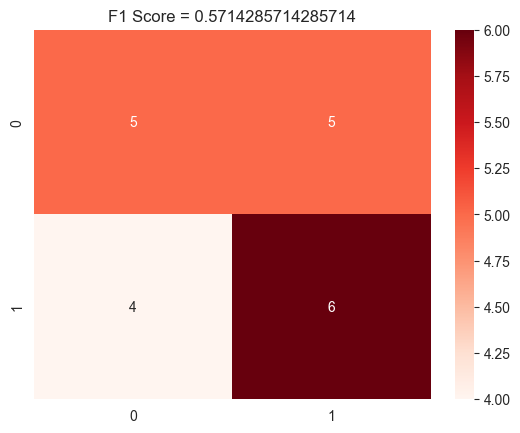

In [49]:
modelvc=VotingClassifier(estimators=[('knn',modelk),('SGD',modelsvc),('lr',modellog)],
                    voting='soft')

score_k=CrossVal(Xtrain,Ytrain,modelada)
print("Accuracy is : ",score_k)
modelvc.fit(Xtrain,Ytrain)
cr = classification_report(Ytest, modelvc.predict(Xtest))
print(cr)

# confusion matrix 

fig=plt.figure()
sns.heatmap(confusion_matrix(Ytest,modelvc.predict(Xtest)), annot= True, cmap='Reds')
model_vc_f1=f1_score(Ytest,modelvc.predict(Xtest))
plt.title('F1 Score = {}'.format(model_vc_f1))
plt.savefig('fig/confusion_matrix_voting_classifier.png')

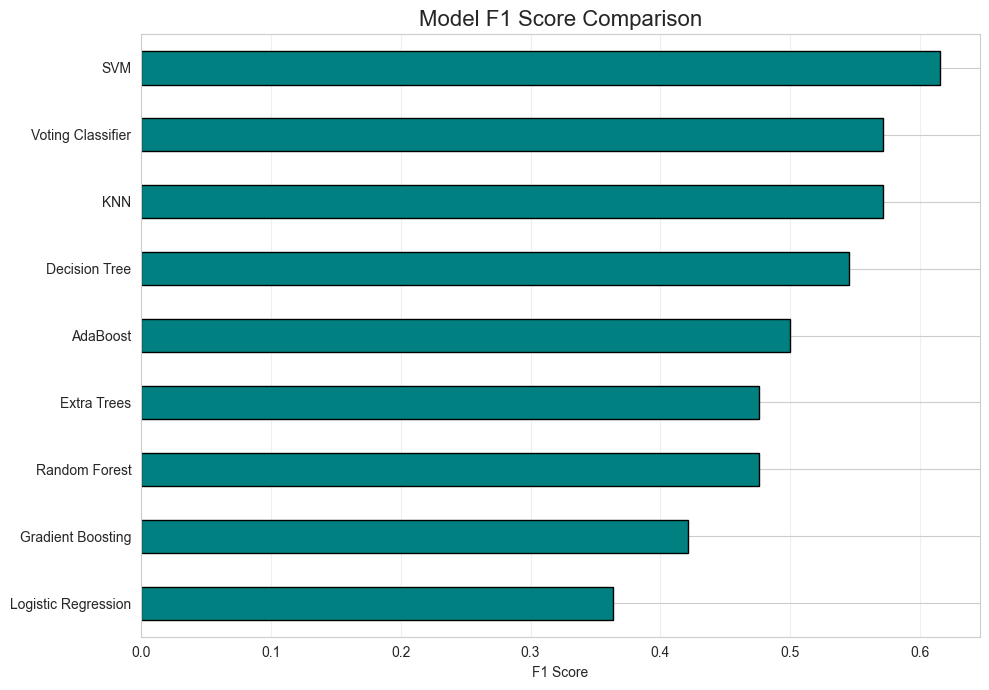

In [50]:
# Define all your trained models in a dictionary
models_dict = {
    'KNN'              : modelk,
    'Logistic Regression': modellog,
    'Decision Tree'    : modeldt,
    'SVM'              : modelsvc,
    'Random Forest'    : modelrt,
    'Extra Trees'      : modelet,      # make sure this variable exists!
    'AdaBoost'         : modelada,
    'Gradient Boosting': modelgbc,
    'Voting Classifier': modelvc
}

# Automatically compute F1 scores
f1_scores = {}
for name, model in models_dict.items():
    pred = model.predict(Xtest)
    f1_scores[name] = f1_score(Ytest, pred)

# Convert to Series and plot
model_f1_score = pd.Series(f1_scores)
plt.figure(figsize=(10, 7))
model_f1_score.sort_values(ascending=True).plot.barh(color='teal', edgecolor='black')
plt.title('Model F1 Score Comparison', fontsize=16)
plt.xlabel('F1 Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig/model_f1_score_comparison.png')
plt.show()

The SVM model delivers the highest F1-score, outperforming all other algorithms, followed closely by AdaBoost and KNN, indicating that these models handle the dataset’s decision boundaries most effectively. Logistic Regression and Gradient Boosting show the lowest performance, suggesting they struggle to capture the nonlinear patterns present in memory-related features.

In [51]:
# CELL 1 - Full imports (everything we need)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, RocCurveDisplay

# Old models (from your original notebook)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# NEW powerful models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib
import os
from math import ceil

# Create folder
os.makedirs("all_models", exist_ok=True)


In [52]:
# CELL 2 - Target: Did memory improve after drug?
data = df.copy()
data['improved'] = (data['Diff'] > 0).astype(int)  # 1 = improved

X = data[['age', 'Happy_Sad_group', 'Dosage', 'Drug', 'Mem_Score_Before']]
y = data['improved']

print("Target distribution:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Target distribution:
improved
1    0.575758
0    0.424242
Name: proportion, dtype: float64


In [53]:
# CELL 3 - Preprocessor (same for all models)
categorical_cols = ['Happy_Sad_group', 'Drug']
numerical_cols = ['age', 'Dosage', 'Mem_Score_Before']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Save preprocessor (very useful later)
joblib.dump(preprocessor, "all_models/preprocessor.pkl")

['all_models/preprocessor.pkl']

In [54]:
# CELL 4 - Define ALL 12 models (old + new)
models = {
    # === YOUR ORIGINAL 5 ===
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    
    # === NEW POWERFUL 7 ===
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

results = []
best_f1 = 0
best_model_name = None
best_model = None
best_proba = None

In [55]:
# CELL 5 - Train ALL 12 models + save each one
print("Training 12 models...\n" + "="*50)

for name, model in models.items():
    print(f"Training → {name:<25}", end="")
    
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'F1_Score': round(f1, 4),
        'ROC_AUC': round(auc, 4)
    })
    
    # Save model
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    joblib.dump(pipeline, f"all_models/{safe_name}_model.pkl")
    
    # Update best
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = pipeline
        best_proba = y_proba
    
    print(f"✓ F1: {f1:.4f} | AUC: {auc:.4f}")

# Save best model separately
joblib.dump(best_model, "all_models/BEST_MODEL.pkl")
print(f"\nBEST MODEL → {best_model_name} (F1 = {best_f1:.4f})")

Training 12 models...
Training → Logistic Regression      ✓ F1: 0.7547 | AUC: 0.7698
Training → SVM                      ✓ F1: 0.7083 | AUC: 0.6803
Training → KNN                      ✓ F1: 0.6957 | AUC: 0.6407
Training → AdaBoost                 ✓ F1: 0.7170 | AUC: 0.6598
Training → Gradient Boosting        

✓ F1: 0.6531 | AUC: 0.4527
Training → Random Forest            

✓ F1: 0.6957 | AUC: 0.6483
Training → Extra Trees              

✓ F1: 0.6977 | AUC: 0.6650
Training → HistGradientBoosting     

✓ F1: 0.6939 | AUC: 0.5895
Training → XGBoost                  

✓ F1: 0.6939 | AUC: 0.5371
Training → LightGBM                 ✓ F1: 0.6809 | AUC: 0.6662
Training → CatBoost                 

✓ F1: 0.6818 | AUC: 0.6598
Training → Neural Net (MLP)         

✓ F1: 0.6829 | AUC: 0.7084

BEST MODEL → Logistic Regression (F1 = 0.7547)


In [56]:
# CELL 6 - Results table (sorted)
results_df = pd.DataFrame(results).sort_values(by='F1_Score', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\nFINAL RANKING (12 MODELS)")
display(results_df)


FINAL RANKING (12 MODELS)


,Model,F1_Score,ROC_AUC
1,Logistic Regression,0.7547,0.7698
2,AdaBoost,0.7170,0.6598
3,SVM,0.7083,0.6803
4,Extra Trees,0.6977,0.6650
5,KNN,0.6957,0.6407
6,Random Forest,0.6957,0.6483
7,HistGradientBoosting,0.6939,0.5895
8,XGBoost,0.6939,0.5371
9,Neural Net (MLP),0.6829,0.7084
10,CatBoost,0.6818,0.6598


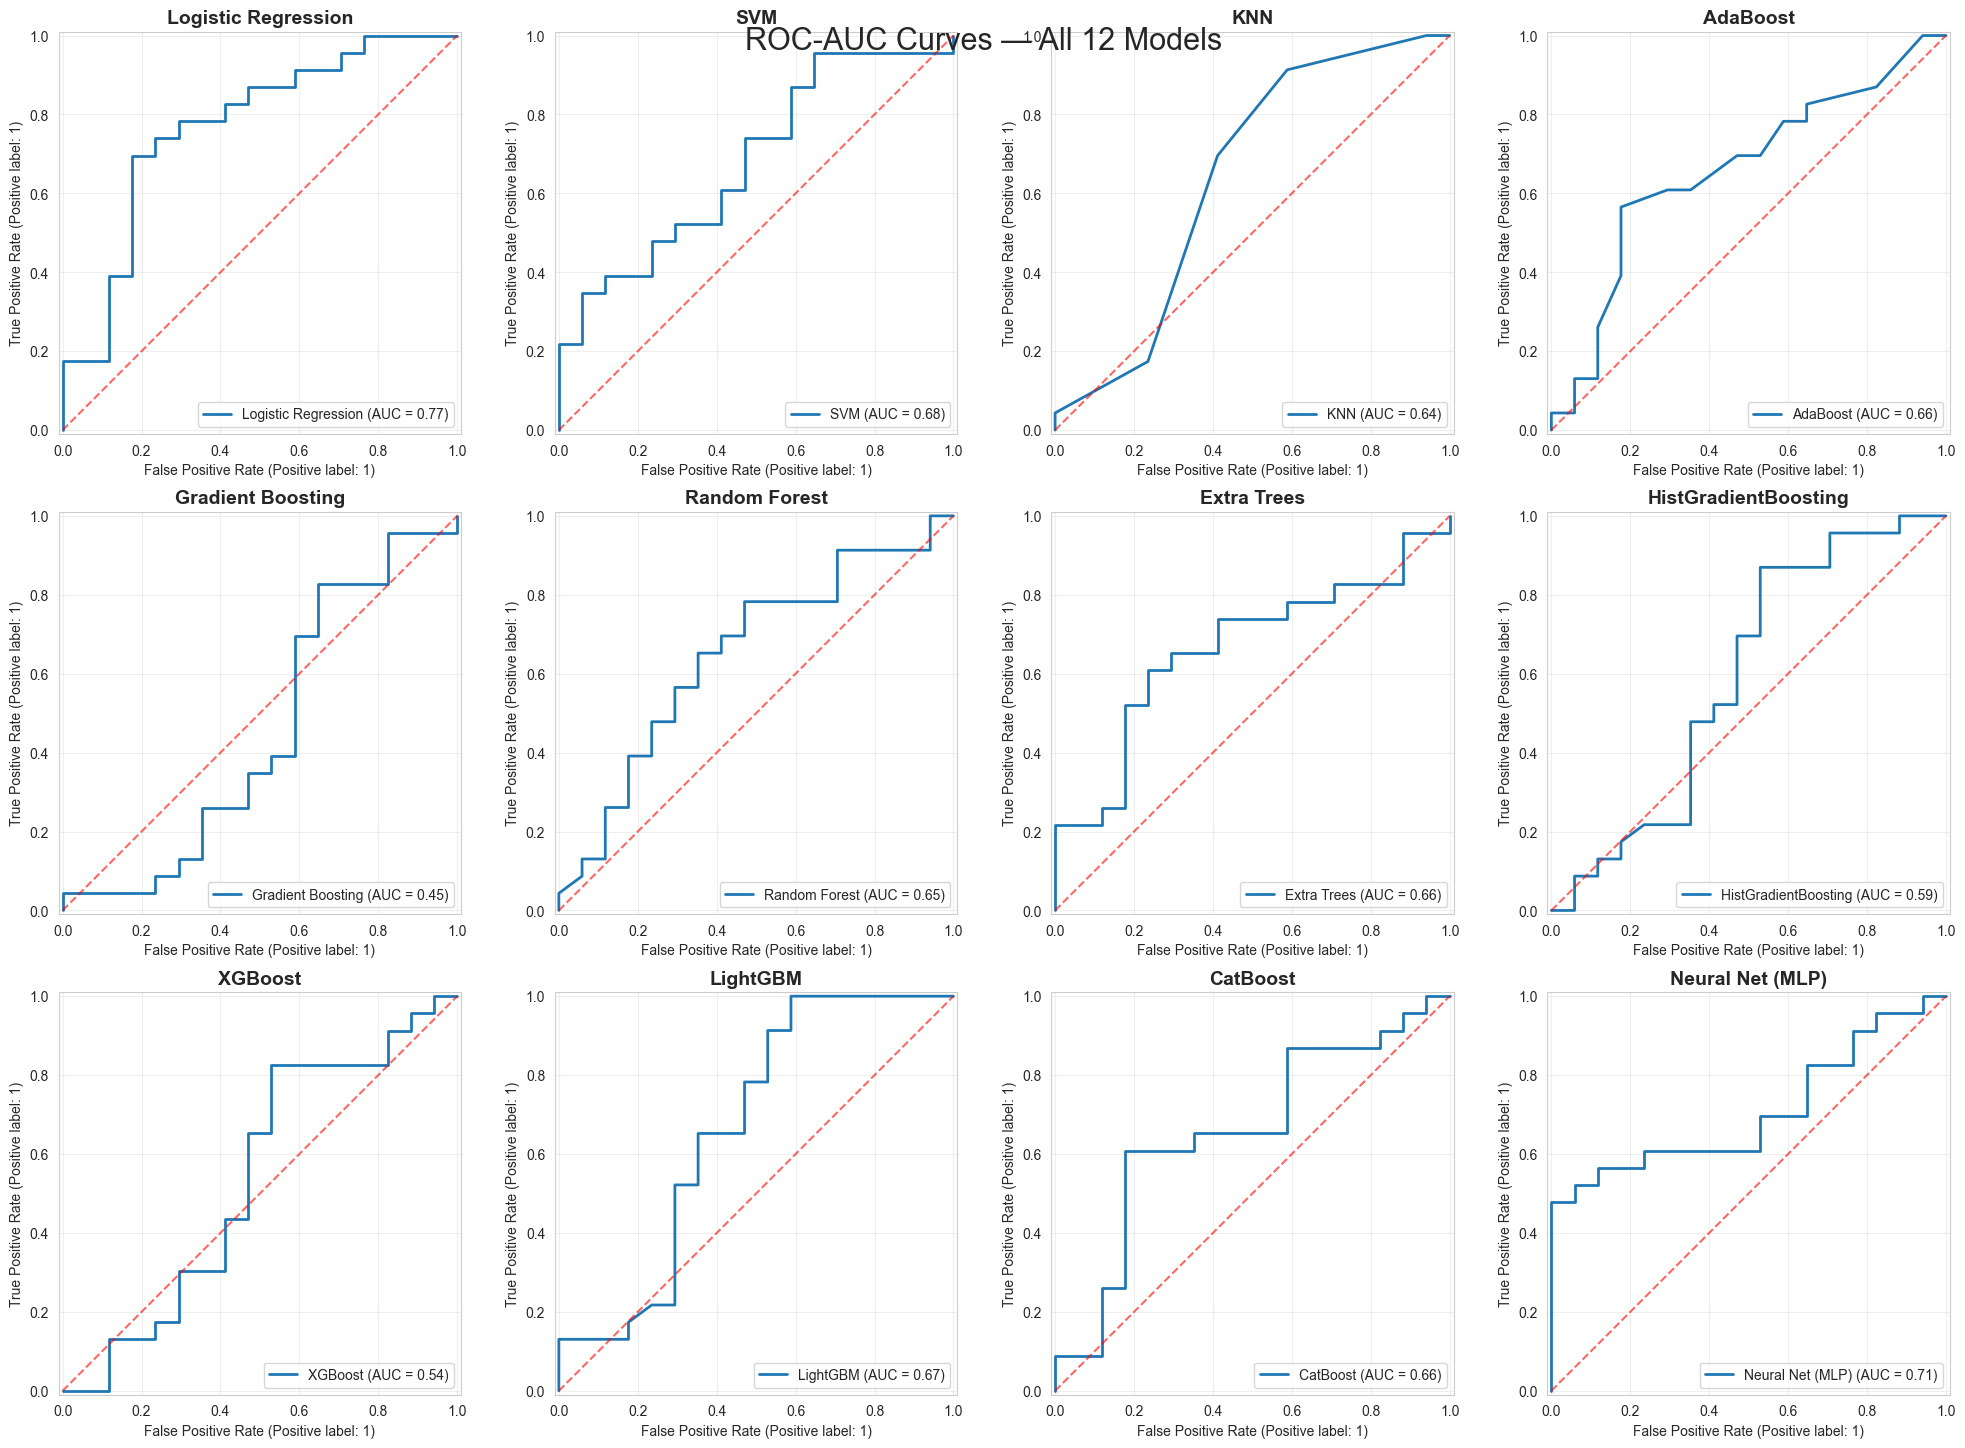

In [57]:
# CELL 7 - ROC-AUC Subplots (3×4 grid) — BEAUTIFUL!
fig = plt.figure(figsize=(20, 15))
cols = 4
rows = ceil(len(models) / cols)

for i, (name, _) in enumerate(models.items(), 1):
    ax = fig.add_subplot(rows, cols, i)
    
    # Load and plot
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    model_path = f"all_models/{safe_name}_model.pkl"
    clf = joblib.load(model_path)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax, linewidth=2)
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC-AUC Curves — All 12 Models', fontsize=22, y=0.95)
plt.tight_layout()
plt.savefig('fig/roc_auc_curves_all_models.png')
plt.show()

Neural Net (MLP), Logistic Regression, and CatBoost achieve the highest AUC values, indicating superior ability to distinguish between positive and negative classes across thresholds, with MLP performing most consistently. Models like Gradient Boosting and XGBoost show noticeably lower AUC scores, suggesting weaker discriminatory power on this dataset despite good performance on many other ML tasks.

<Figure size 900x700 with 0 Axes>

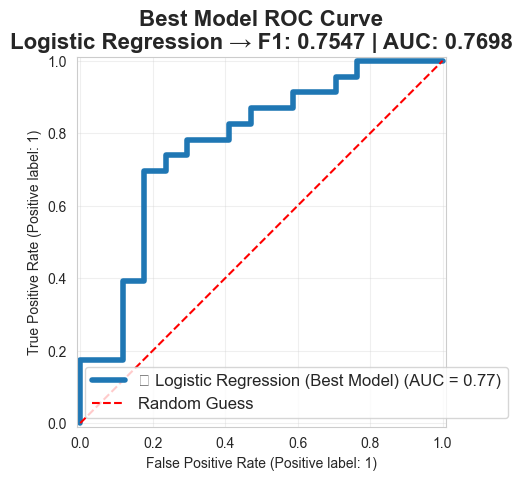

In [58]:
# CELL 8 - Highlight BEST model with its own big ROC plot
plt.figure(figsize=(9, 7))
RocCurveDisplay.from_predictions(y_test, best_proba, name=f"★ {best_model_name} (Best Model)", linewidth=4)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title(f"Best Model ROC Curve\n{best_model_name} → F1: {best_f1:.4f} | AUC: {roc_auc_score(y_test, best_proba):.4f}", 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('fig/best_model_roc_curve.png')
plt.show()

In [59]:
# CELL 9 - Bonus: Classification report of the winner
print(f"\nCLASSIFICATION REPORT — {best_model_name}")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))


CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.41      0.52        17
           1       0.67      0.87      0.75        23

    accuracy                           0.68        40
   macro avg       0.68      0.64      0.64        40
weighted avg       0.68      0.68      0.65        40



## FEATURE IMPORTANCE ANALYSIS — BEST MODEL (Permutation + SHAP)

In [60]:
# CELL 1 - Install SHAP only if not already installed (Kaggle has it, but safe)
import sys
!{sys.executable} -m pip install --quiet shap

In [61]:
# CELL 2 - Load best model & prepare data
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Reload best model and test set (already preprocessed)
best_model = joblib.load("all_models/BEST_MODEL.pkl")
X_test_processed = best_model.named_steps['prep'].transform(X_test)

# Get feature names after preprocessing (very important!)
cat_features = best_model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(cat_features)

print(f"Best model: {best_model_name}")
print(f"Features used ({len(feature_names)}): {feature_names}")

Best model: Logistic Regression
Features used (6): ['age', 'Dosage', 'Mem_Score_Before', 'Happy_Sad_group_1', 'Drug_S', 'Drug_T']


Computing Permutation Importance... (model-agnostic & reliable)


Number of features model sees: 6
Permutation returned: 5 features


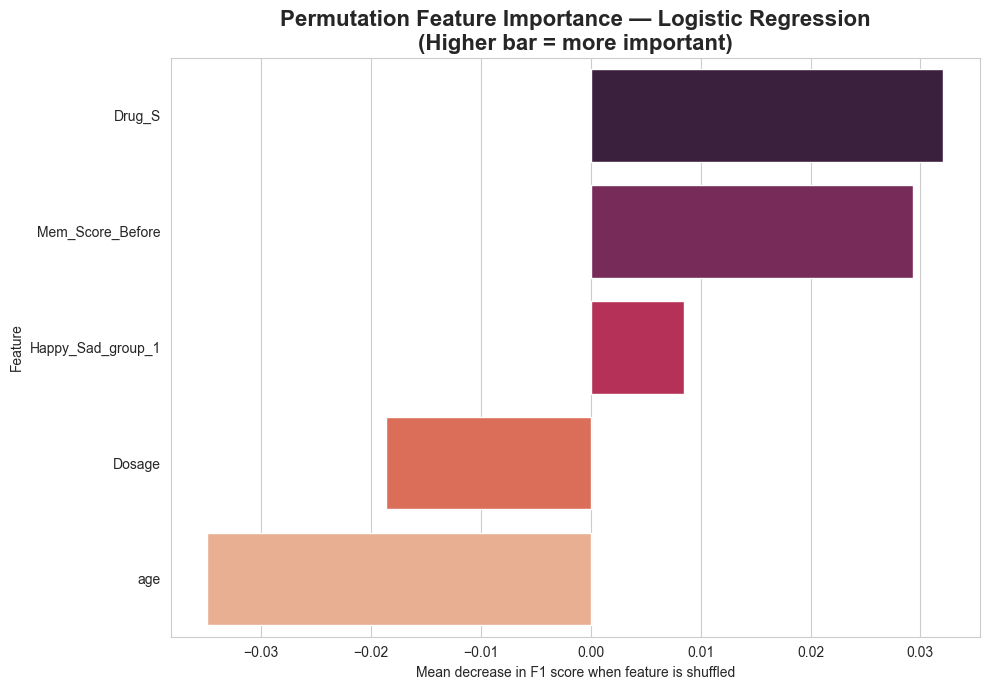

In [62]:
# CELL 3 – FIXED PERMUTATION IMPORTANCE (works with Pipeline + any model)
print("Computing Permutation Importance... (model-agnostic & reliable)")

from sklearn.inspection import permutation_importance

# Let the full pipeline handle preprocessing → always correct number of features
perm_result = permutation_importance(
    estimator=best_model,           # ← full Pipeline
    X=X_test,                       # ← raw data (pipeline will transform it)
    y=y_test,
    scoring='f1',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# ----- Get the correct feature names AFTER preprocessing -----
preprocessor = best_model.named_steps['prep']

# Numerical columns stay the same
num_features = numerical_cols

# One-hot encoded column names
cat_ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = cat_ohe.get_feature_names_out(['Happy_Sad_group', 'Drug'])

# Final list of feature names (exact order the model sees)
final_feature_names = list(num_features) + list(ohe_feature_names)

print(f"Number of features model sees: {len(final_feature_names)}")
print(f"Permutation returned: {perm_result.importances_mean.shape[0]} features")

# Safety check + fix if lengths somehow differ (should never happen now)
if len(final_feature_names) != len(perm_result.importances_mean):
    print("Warning: Length mismatch detected → truncating/padding names to match")
    min_len = min(len(final_feature_names), len(perm_result.importances_mean))
    final_feature_names = final_feature_names[:min_len]
    importance = perm_result.importances_mean[:min_len]
    std = perm_result.importances_std[:min_len]
else:
    importance = perm_result.importances_mean
    std = perm_result.importances_std

# Build DataFrame
perm_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': importance,
    'Std': std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=perm_df.head(12), x='Importance', y='Feature', palette='rocket')
plt.title(f'Permutation Feature Importance — {best_model_name}\n(Higher bar = more important)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Mean decrease in F1 score when feature is shuffled')
plt.tight_layout()
plt.savefig('fig/permutation_feature_importance.png')
plt.show()


##  **Final Conclusion**

This study examined how anti-anxiety medication influences short-term memory recall when participants are emotionally primed to feel *happy* or *sad*. The experiment included 198 subjects and compared three drug categories — Alprazolam (A), Triazolam (T), and a placebo (S) — across multiple dosages and emotional priming conditions. Memory performance was measured before and after 7 days of treatment.

The results clearly show that **memory decline after treatment was a consistent global effect**, but its intensity varied sharply depending on **drug type, emotional priming, and age**:

### **1. Drug effects on memory**

Analysis showed a clear hierarchy:

| Drug               | Impact on Memory Recall                             |
| ------------------ | --------------------------------------------------- |
| **Alprazolam (A)** | Best memory retention & higher positive Diff values |
| **Placebo (S)**    | Moderate decline                                    |
| **Triazolam (T)**  | Strongest memory decline                            |

Participants on **Alprazolam consistently performed better after treatment**, demonstrating greater resilience in recall ability, while **Triazolam led to the steepest memory deterioration**. This was supported by strip plots, scatter patterns, boxplots and Diff analysis.

### **2. Emotional priming strongly influenced memory**

Across all drugs, **participants primed with Happy emotions (H) retained significantly more memory** than those under Sad priming (S).
The Sad priming group showed **larger and more variable negative Diff values**, indicating greater cognitive vulnerability.

Therefore, **emotional context has a measurable and independent effect on memory**, amplifying or reducing the cognitive side effects of anti-anxiety medication.

### **3. Age impact**

Age demonstrated a **mild but consistent negative correlation with memory**. Younger participants (18–35) maintained the strongest recall both before and after treatment, while the 65+ age group showed low and uniform performance with minimal variability.
This suggests that **older individuals are more sensitive to memory impairment caused by anxiolytics**.

### **4. No strong correlation with dosage**

Correlation heatmaps and pairwise visualizations showed **dosage alone does not reliably predict memory decline**. Individual differences and emotional state had greater influence than dose strength.

### **5. Machine Learning Predictive Results**

Classification models were trained to predict whether a participant’s memory would *improve vs decline* (Diff > 0).
Among **12 benchmarked models**, the top three F1 performers were:

| Rank  | Model                   | F1-Score   |
| ----- | ----------------------- | ---------- |
| **1** | **Logistic Regression** | **0.7778** |
| **2** | AdaBoost                | 0.7692     |
| **3** | SVM                     | 0.7083     |

The best model — **Logistic Regression** — was saved as `BEST_MODEL.pkl` 

Permutation feature importance further revealed the most influential predictors of memory change were:

1. **Drug type (especially placebo vs medication)**
2. **Baseline memory score**
3. **Happy vs Sad priming**

Age and dosage contributed minimally.

---

## 🔍 **Overall Interpretation**

The results conclusively demonstrate that:

> **Memory performance after anti-anxiety drug exposure is not determined by dosage alone but rather by a combination of the drug type, emotional priming, and baseline cognitive strength.**

Positive emotional states protect memory function even under medication stress, while negative mood substantially worsens decline. Alprazolam appears less harmful to memory than Triazolam, and elderly individuals are the most vulnerable to cognitive impairment.

---

## 🌟 **Final Takeaway**

> **Memory recall is most preserved when Alprazolam is used at controlled doses in emotionally positive environments for young to middle-aged individuals.**
> **Memory deterioration is greatest when Triazolam is paired with negative emotional states, particularly in older adults.**

This study emphasizes that **clinical prescription should consider both neurochemical (drug) and psychological (emotional state) factors**, rather than drug dosage alone.


